# Raport: Predykcja przepustowości ruchu internetowego (Upload)

## 1. Cel eksperymentu
Głównym zadaniem badawczym jest predykcja rzeczywistej maksymalnej przepływności wysyłania danych, określanej za pomocą parametru `bytes_sec` (bajty na sekundę). Monitorowanie i prognozowanie ruchu sieciowego pozwala dostawcom usług internetowych (ISP) na inteligentne zarządzanie zasobami, optymalizację węzłów telekomunikacyjnych oraz dynamiczne modelowanie przydziału pasma w oparciu o cykle dobowe użytkowników.

---
## 2. Dane i Preprocessing
Eksperyment został przeprowadzony na publicznych logach sieciowych pochodzących z programu **FCC Measuring Broadband America** (zestaw danych `data-raw-2023-feb`). Analizie poddano logi z testów wysyłania danych (upload) pobierane z pliku `curr_lct_ul.csv`.

Dane poddano następującym modyfikacjom przed podaniem ich do modeli maszynowych:
* **Czyszczenie**: Odrzucono wszelkie wiersze z brakiem celu (czyli brakiem pomiaru prędkości `bytes_sec` lub wartością mniejszą/równą zeru). Pozostałe puste komórki uzupełniono zerami lub wartościami `-1`.
* **Inżynieria Cech Czasowych**: Z logu czasowego `dtime` wyodrębniono dodatkowe atrybuty o relacji sezonowej: godzinę (`hour`) oraz numer dnia tygodnia (`day_of_week`). Pozwala to na dokładniejsze uczenie się tych cech przez algorytmy.
* **Zmienne Kategoryczne**: Konwersja zmiennych tekstowych na wartości numeryczne, np. serwerów odbierających ping (`target`) oraz flag błędów (`error_code`) przy użyciu biblioteki `LabelEncoder`.
* **Skalowanie Transformatorowe**: W ramach obiektów *Pipeline* wszystkie cechy przepuszczano przez `StandardScaler`, by wyśrodkować średnią do 0 i wariancję do 1 (zabieg wykonywany ze względu na wymagania modelu przestrzennego MLP).

---
## 3. Charakterystyka algorytmów predykcyjnych
W badaniu wykorzystano trzy zróżnicowane estymatory regresyjne, stanowiące standard w analizie danych ustrukturyzowanych. Wszystkie algorytmy pochodzą z biblioteki `scikit-learn`.

### A. [Random Forest Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor) (Las Losowy)
* **Charakterystyka**: Model zespołowy oparty na technice *baggingu*. Generuje liczne, niezależne drzewa decyzyjne na losowych podzbiorach danych i cech. Wynik końcowy jest średnią predykcji wszystkich drzew.
* **Zasadność**: Wykazuje wysoką odporność na wartości odstające i szumy w logach sieciowych. Bardzo dobrze radzi sobie z cechami kategorycznymi i jest standardem dla danych tabelarycznych.
* **Ograniczenia**: Model ma trudności z ekstrapolacją danych (nie przewidzi wartości spoza zakresu treningowego). Przy dużej liczbie drzew może cechować się dużym zapotrzebowaniem na pamięć RAM. Zastosowano parametry które redukują zapotrzebowanie pamięciowe, uzyskując nadal satysfakcjonujące wyniki.
* **Parametry**:
    * `n_estimators`: 100-200 (liczba drzew).
    * `max_depth`: 15-25 (ograniczenie głębokości w celu uniknięcia overfittingu).
    * `min_samples_split`: 2-5 (minimalna liczba próbek do podziału węzła).

### B. [Gradient Boosting Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html) (Wzmocnienie Gradientowe)
* **Charakterystyka**: Algorytm typu *boosting*, budujący sekwencję "słabych" drzew. Każde kolejne drzewo jest optymalizowane pod kątem redukcji błędów popełnionych przez poprzednie jednostki, za pomocą właśnie rachunku różniczkowego (spadku gradientu), skąd pochodzi nazwa.
* **Zasadność**: Uznawany za model o najwyższej precyzji dla danych tabelarycznych. Dzięki optymalizacji po pochodnej funkcji kosztu potrafi bardzo dokładnie odwzorować skomplikowane wzorce. 
* **Ograniczenia**: Proces uczenia jest sekwencyjny, co wydłuża czas treningu. Model jest czuły na hiperparametry i może szybko ulec przeuczeniu przy zbyt dużej liczbie iteracji.
* **Parametry**:
    * `learning_rate`: 0.01 - 0.1 (tempo adaptacji).
    * `n_estimators`: 500+ (liczba etapów wzmocnienia).
    * `subsample`: 0.8 (użycie fragmentu danych do budowy drzewa w celu poprawy generalizacji).

### C. [Multi-Layer Perceptron](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html) (MLP - Gęsta Sieć Neuronowa)
* **Charakterystyka**: Wielowarstwowa sieć neuronowa *feed-forward*. Wykorzystuje warstwy ukryte z nieliniowymi funkcjami aktywacji do aproksymacji złożonych zależności matematycznych.
* **Zasadność**: Pozwala na odkrycie wysokopoziomowych abstrakcji i nieliniowych korelacji, które mogą zostać pominięte przez klasyczne modele statystyczne.
* **Ograniczenia**: Model typu "czarna skrzynka" – trudna interpretacja wag. Wymaga pełnej standaryzacji danych (`StandardScaler`) i jest bardzo wrażliwy na szum informacyjny.
* **Parametry**:
    * `hidden_layer_sizes`: (256, 128, 64) – struktura redukująca wymiarowość.
    * `alpha`: 0.005 – parametr regularyzacji L2.
    * `batch_size`: 512 – liczba próbek w jednej iteracji optymalizatora Adam.



## 4. Prezentacja wyników eksperymentu
Kod treningowy wygenerował gotowy plik z zestawieniem pod wybrane metryki regresji: Błędy względne oraz bezwzględne m.in: MAE, RMSE, MAPE. Prezentujemy poniżej jego analityczną formę graficzną i numeryczną.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# Pamiętamy z pliku *.py, że 3 modele zostają wrzucane do górnej tabeli 
df_results = pd.read_csv("wyniki_predykcji.csv", nrows=3)

# Oczyszczenie tabeli nagłówkowych (dla porządku danych wyświetlanych)
if "Model" not in df_results.columns:
    df_results.rename(columns={'Unnamed: 0': 'Model', 'R²': 'R2'}, inplace=True)
else:
    df_results.rename(columns={'R²': 'R2'}, inplace=True)

# Formatowanie tabeli
display(df_results.style.format({
    "MAE": "{:,.2f}",
    "RMSE": "{:,.2f}",
    "R2": "{:.4f}",
    "MAPE (%)": "{:.2f}%",
    "MedAE": "{:,.2f}",
    "Max Error": "{:,.2f}",
    "EVS": "{:.4f}"
}).hide(axis="index"))

Model,MAE,RMSE,MedAE,Max Error,R2,EVS,MAPE (%)
Random Forest,"23,949.49","1,086,522.23",786.58,"232,588,106.70",0.9942,0.9942,0.29%
Gradient Boosting,"39,180.20","548,921.52","10,063.50","142,287,190.99",0.9985,0.9985,3.33%
MLP,"516,686.97","5,005,437.93","68,111.98","398,196,363.35",0.8768,0.8768,22.58%



### Wykresy analityczne

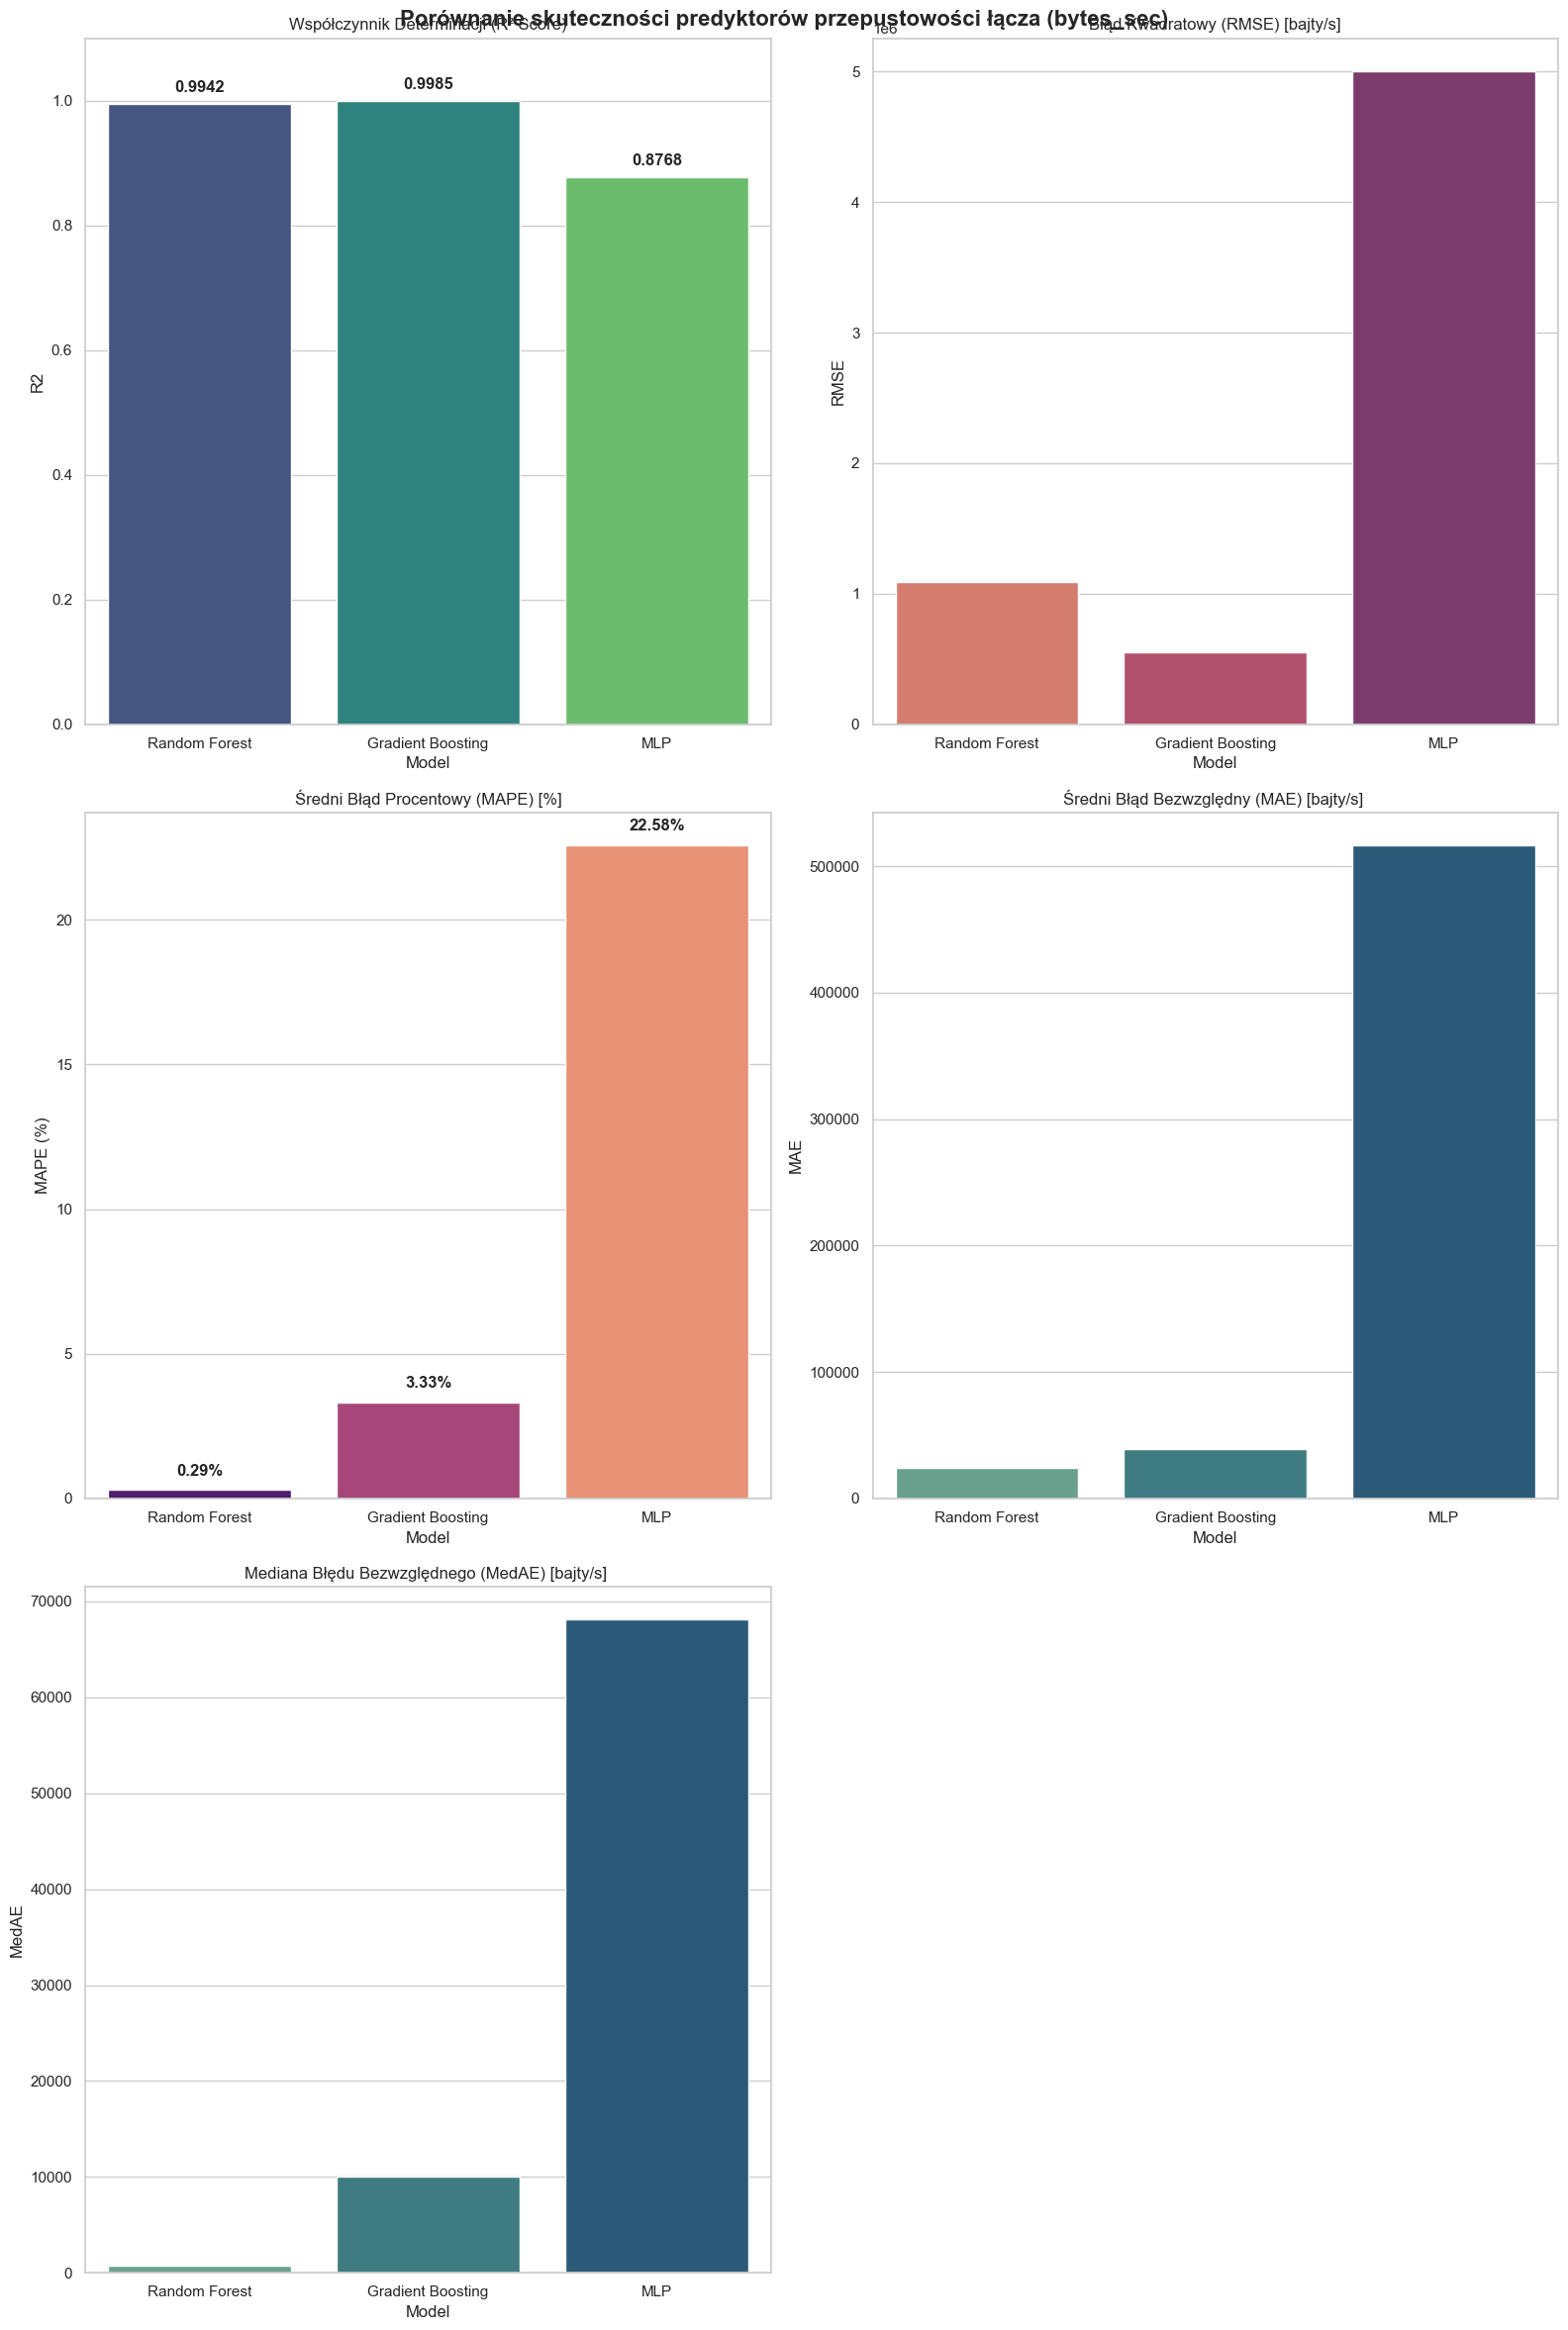

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(16, 24))
fig.suptitle('Porównanie skuteczności predyktorów przepustowości łącza (bytes_sec)', fontsize=16, fontweight='bold')

# R2 Score Plot
sns.barplot(data=df_results, x='Model', y='R2', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Współczynnik Determinacji (R² Score)')
axes[0, 0].set_ylim(0, 1.1)
for i, val in enumerate(df_results['R2']):
    axes[0, 0].text(i, val + 0.02, f'{val:.4f}', ha='center', fontweight='bold')

# MAPE Plot
sns.barplot(data=df_results, x='Model', y='MAPE (%)', ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Średni Błąd Procentowy (MAPE) [%]')
for i, val in enumerate(df_results['MAPE (%)']):
    axes[1, 0].text(i, val + 0.5, f'{val:.2f}%', ha='center', fontweight='bold')

# MAE Plot
sns.barplot(data=df_results, x='Model', y='MAE', ax=axes[1, 1], palette='crest')
axes[1, 1].set_title('Średni Błąd Bezwzględny (MAE) [bajty/s] ')

# MedAE Plot
sns.barplot(data=df_results, x='Model', y='MedAE', ax=axes[2, 0], palette='crest')
axes[2, 0].set_title('Mediana Błędu Bezwzględnego (MedAE) [bajty/s] ')

# RMSE Plot
sns.barplot(data=df_results, x='Model', y='RMSE', ax=axes[0, 1], palette='flare')
axes[0, 1].set_title('Błąd Kwadratowy (RMSE) [bajty/s]')

fig.delaxes(axes[2, 1])


plt.tight_layout()
plt.show()

## 5. Wnioski 

**1. Bezwzględny Zwycięzca: Modele Drzewiaste (Gradient Boosting i Random Forest)**

Jak widać po wykresach, algorytm **Gradient Boosting** osiągnął nadzwyczaj dobry wynik dla tych danych, notując wynik R² na poziomie **0.9985**, stanowiący bardzo wysoką korelację trafień. Random Forest podąża za nim minimalnie z wynikiem **0.994**. MLP natomiast uzyskało wynik najgorszy, jednak nadal satysfakcjonujący z R² równym **0.8768**.

**2. Margines i tolerancja błędu w praktyce inżynieryjnej**

Bardzo interesująco prezentuje się metryka MAE %. Las Losowy (Random Forest) osiąga bardzo niski błąd względny na poziomie **~0.29%**, a wzmocnienie gradientowe **~3.33%**. Te predyktory są wyjątkowo dokładne. Co ważne z punktu widzenia projektowego – MAE rzędu 23 tysięcy bajtów brzmi na olbrzymią liczbe (czyli ~23KB/s) jednak gdy weźmiemy pod uwage łącza klientów pędzące po kilkadziesiąt/set Megabajtów to te szacowane straty odchyłów wykazanych w RMSE stanowią dla operatora promil pomyłki statystycznej z zachowaniem idealnej proporcji. Ciekawe w tym przypadku jest to, że mimo niższego wyniku R², to jednak las losowy popełnia średnio niższe błędy względne. To współczynnik RMSE w większym stopniu koreluje z R² dla danego algorytmu.

**3. Ograniczenia dla Sieci Neuronowej (MLP)**

Co typowe dla środowisk tabelarycznych, prosta głęboka sieć Multi-Layer Perceptron wypada gorzej pod względem stabilności (MAPE ok ~22% oraz R² ok. 0.87) gubiąc korelację w dużych pikach zawierających dane sieciowe. Weryfikuje to branżowe standardy: 
>Do ustrukturalizowanych logów infrastruktury (telemetrycznych po cechach numerycznych bez obrazu/tekstów) modele oparte na ensemble'ach drzewiastych są wciąż liderem Data Science i predykcji analitycznej.

>Léo Grinsztajn, Edouard Oyallon, and Gaël Varoquaux. 2022. Why do tree-based models still outperform deep learning on typical tabular data? In Proceedings of the 36th International Conference on Neural Information Processing Systems (NIPS '22). Curran Associates Inc., Red Hook, NY, USA, Article 37, 507–520.